In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Ejercicio N°3**

Importe y explore el conjunto de datos `titanic.csv`.

1. Realice una descripción general del conjunto de datos que incluya la descripción de la información brindada por cada columna, el tipo de datos que contiene cada una y el número de registros.

2. Realice cualquier tipo de limpieza y adecuación del dataset que considere necesaria para su posterior análisis, incluyendo manejo de valores faltantes y de datos duplicados y/o potencialmente erróneos.

In [3]:
titanic=pd.read_csv('./datasets/titanic.csv')

In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   object 
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   object 
 16  Boarded      1304 non-null   object 
 17  Destination  1304 non-null   object 
 18  Lifeboat     502 non-null    object 
 19  Body  

In [5]:
#dropeo las columnas con muchos NA
col_NA=['Cabin','Lifeboat','Body']
titanic=titanic.drop(columns=col_NA)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,3.0


In [14]:
print(f"\nRegistros duplicados: {titanic.duplicated().sum()}")


Registros duplicados: 0


In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Embarked     1307 non-null   object 
 11  WikiId       1304 non-null   float64
 12  Name_wiki    1304 non-null   object 
 13  Age_wiki     1302 non-null   float64
 14  Hometown     1304 non-null   object 
 15  Boarded      1304 non-null   object 
 16  Destination  1304 non-null   object 
 17  Class        1304 non-null   float64
dtypes: float64(6), int64(4), object(8)
memory usage:

3. Calcule la media, la mediana y la desviación estándar de la edad de los/las pasajeros/as que murieron y sobrevivieron para cada clase. Realice un boxplot que muestre la distribución de edades para cada grupo (murieron/sobrevivieron) dentro de cada clase. ¿En qué clase las edades de las personas que sobrevivieron fueron más variables? ¿Cuál fue la edad de la persona más joven que sobrevivió en tercera clase?

In [7]:
titanic.groupby(['Pclass', 'Survived'])['Age'].agg(['mean', 'median', 'std']).round(2)

mean  median    std
Pclass Survived                      
1      0.0       43.70   45.25  15.28
       1.0       35.37   35.00  13.76
2      0.0       33.54   30.50  12.15
       1.0       25.90   28.00  14.84
3      0.0       26.56   25.00  12.33
       1.0       20.65   22.00  12.00

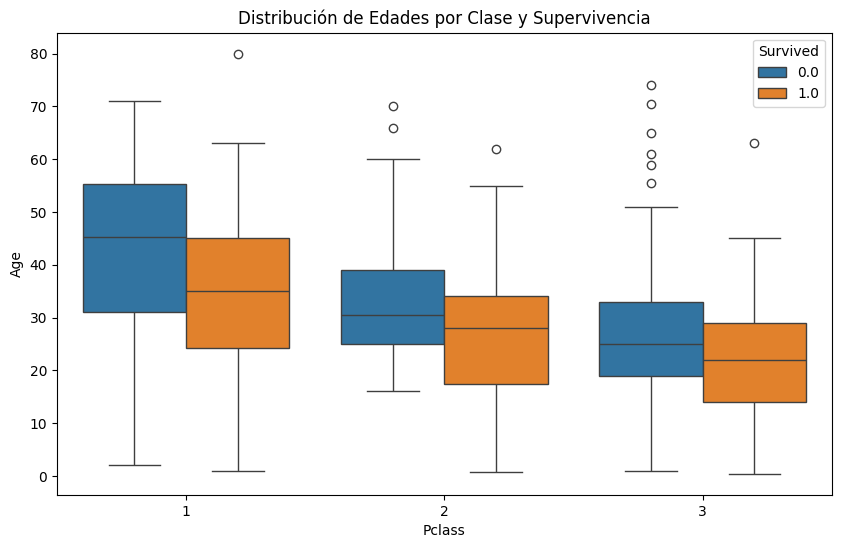

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', hue='Survived', data=titanic)
plt.title('Distribución de Edades por Clase y Supervivencia')
plt.show()

En la primera clase hay mayor varianza de edad de sobrevivientes

In [11]:
joven_3ra = titanic[(titanic['Pclass'] == 3) & (titanic['Survived'] == 1)]['Age'].min()
print(f"El sobreviviente más joven de 3ra clase tenía: {joven_3ra} años")

El sobreviviente más joven de 3ra clase tenía: 0.42 años


4. Represente gráficamente la distribución de los precios de los pasajes en función de la clase del pasajero y calcule el promedio, la moda, la mediana, la desviación estándar y el rango intercuartil del precio del pasaje para cada grupo. ¿En qué clase los precios de pasaje presentaron una mayor variabilidad?

In [20]:
#tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

precio=titanic.groupby('Pclass')['Fare'].agg(['mean', lambda x: x.mode()[0], 'median', 'std', iqr]).round(2)
precio.columns=['Promedio', 'Moda','Mediana','Desviacion estandar','Rango intercuartil']
precio

,Promedio,Moda,Mediana,Desviacion estandar,Rango intercuartil
Pclass,,,,,
1,87.51,26.55,60.00,80.45,76.97
2,21.18,13.00,15.05,13.61,13.00
3,13.30,8.05,8.05,11.49,7.50


5. 
- ¿Qué medida resumen calcularía si quisiera conocer aquel valor que representa el precio que sólo el 25% de los pasajeros superaron a la hora de comprar su boleto? 

In [24]:
top25=titanic['Fare'].quantile(0.25)
print(f'Solo el 25% de los pasajeros superaron el precio de $ {round(top25,2)}')

Solo el 25% de los pasajeros superaron el precio de $ 7.9


- Identifique cuáles fueron los pasajeros que pagaron un pasaje igual o más caro que el valor calculado en el ítem anterior. Construya una tabla en la que se informen los nombres de estas personas, el número total de personas vinculadas a ellas que se encontraban en el barco y la ciudad en la que embarcaron.

In [26]:
pagan_caro=titanic[(titanic['Fare']>=top25)]
pagan_caro[['Name','Boarded','SibSp','Parch']]

,Name,Boarded,SibSp,Parch
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cherbourg,1,0
2,"Heikkinen, Miss. Laina",Southampton,0,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Southampton,1,0
4,"Allen, Mr. William Henry",Southampton,0,0
5,"Moran, Mr. James",Queenstown,0,0
...,...,...,...,...
1302,"Minahan, Mrs. William Edward (Lillian E Thorpe)",Southampton,1,0
1304,"Spector, Mr. Woolf",Southampton,0,0
1305,"Oliva y Ocana, Dona. Fermina",Cherbourg,0,0
1307,"Ware, Mr. Frederick",Southampton,0,0


- En base a la tabla construida en el ítem anterior, ¿con cuántos acompañantes, en promedio, viajaban estos pasajeros? ¿En qué puerto embarcó la mayoría de ellos?


In [29]:
pagan_caro['Vinculados']=pagan_caro['SibSp']+pagan_caro['Parch']
pagan_caro[['Name','Boarded','Vinculados']]

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_20752\3526108276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pagan_caro['Vinculados']=pagan_caro['SibSp']+pagan_caro['Parch']


,Name,Boarded,Vinculados
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cherbourg,1
2,"Heikkinen, Miss. Laina",Southampton,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Southampton,1
4,"Allen, Mr. William Henry",Southampton,0
5,"Moran, Mr. James",Queenstown,0
...,...,...,...
1302,"Minahan, Mrs. William Edward (Lillian E Thorpe)",Southampton,1
1304,"Spector, Mr. Woolf",Southampton,0
1305,"Oliva y Ocana, Dona. Fermina",Cherbourg,0
1307,"Ware, Mr. Frederick",Southampton,0


In [35]:
media_parientes=pagan_caro['Vinculados'].mean().round(0)
print(f'Viajaban en promedio con {media_parientes} parientes acompañantes')
mas_embarques=pagan_caro['Boarded'].mode()[0]
print(f'La ciudad con mas embarques de los que pagan caro fue {mas_embarques}')

Viajaban en promedio con 1.0 parientes acompañantes
La ciudad con mas embarques de los que pagan caro fue Southampton


6. Construya una tabla en la que se resuma la distribución de pasajeros del Titanic en función de la clase en la que viajaron. La misma debe contener la siguiente información (en distintas columnas): cantidad de pasajeros/as que viajaron en cada clase y porcentajes en relación al total. ¿A qué clase pertenecía la mayoría de los pasajeros del Titanic?

In [42]:
frec_abs=titanic['Pclass'].value_counts().sort_index()
frec_rel=titanic['Pclass'].value_counts(normalize=True).sort_index().round(2)*100

tabla=pd.DataFrame({'Cantidad pasajeros':frec_abs,
                   'Porcentaje':frec_rel})
tabla

,Cantidad pasajeros,Porcentaje
Pclass,,
1,323,25.0
2,277,21.0
3,709,54.0


7. Construya una tabla de contingencia cruzando las variables `survived` y `Pclass`. ¿Qué proporción de personas de cada clase sobrevivieron al naufragio del Titanic? Represente gráficamente esta información en un gráfico de barras.

In [53]:
#se hace un crosstab
contingencia = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index').round(2) * 100
contingencia.columns=['Murio','Sobrevivio']
contingencia

,Murio,Sobrevivio
Pclass,,
1,37.0,63.0
2,53.0,47.0
3,76.0,24.0


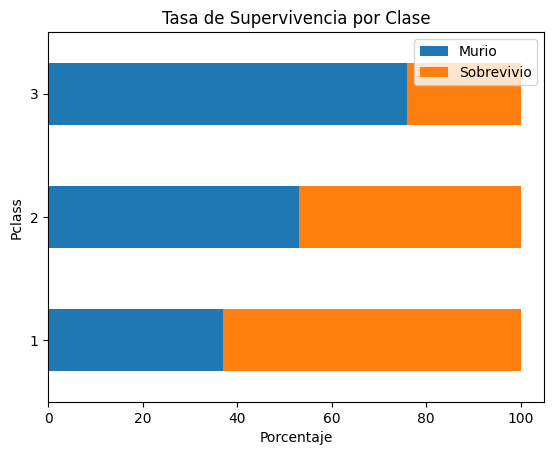

In [58]:
contingencia.plot(kind='barh', stacked=True)
plt.title('Tasa de Supervivencia por Clase')
plt.xlabel('Porcentaje')
plt.show()